> Two Ways to Handle Missing values:
1. Remove them(remove that row where mising val is present) - Means CCA(Complete Case Analysis)
2. Impute them(impute missing val with something)

> Imputing

a. Univariate(SimpleImputer)

1. Numerical -> Impute using these val:
- Mean/Median/Mode
- Random values
- End of Distributn
- Arbitrary No
- Missing Indicator

2. Categorical -> Impute using:
- Mode
- Missing word

b. Multivariate
1. KNN imputer
2. Iterative imputer(MICE)


# Removing Values

> CCA(Complete Case Analysis)
- CCA also called as 'list wise deletn' of cases consists in discarding rows(observatn) where val in any of the cols(var) are missing.
- CCA means literally analyzing only those observatn for which there is info in all of the var in the dataset
- Means removing rows of that colmn in which values is missing

> Assumptions for CCA
- MCAR(Missing Colns At Random) means remove values only When Values Are Missing At Random places 
- Means When Top/Bottom/Mid places Continuous Values Are Missing 
- Perform when missing vals < 5-10%

> Advantages of CCA
- Easy to implement as no data manipulatn required
- Preserves Var Distributn(if data is MCAR, then distribtn of var of reduced dataset should match distribtn in original dataset)

> Disadvantages of CCA
- It can exclude a large fractn of original dataset(if missing data is more/abundant)
- Excluded obs could be informative for analysis(if data is not missing at random)
- When using our models in productn, the model will not know how to handle missing data

> When to use CCA
- MCAR
- When Missing Data is less than 5%

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r'C:\Users\HP\OneDrive\Desktop\python\pyCourse\csvFiles\data_science_job.csv')

In [3]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [ ]:
# finding missing percentage of data colmnwise
df.isnull().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

- So here we can only apply CCA on city_dev, enroll_uni, edu, trainin_hr cols s they have missing values below 5%

In [3]:
# getting cols with less than 5% missing data
cols = [var for var in df.columns if df[var].isnull().mean() < 0.05 and df[var].isnull().mean() > 0]
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [9]:
df[cols].head()

,city_development_index,enrolled_university,education_level,experience,training_hours
0,0.920,no_enrollment,Graduate,20.0,36.0
1,0.776,no_enrollment,Graduate,15.0,47.0
2,0.624,Full time course,Graduate,5.0,83.0
3,0.789,NaN,Graduate,0.0,52.0
4,0.767,no_enrollment,Masters,20.0,8.0


In [ ]:
# finding proportion of non-missing vals in cols wrt to df
len(df[cols].dropna()) / len(df)

0.8968577095730244

In [4]:
new_df = df[cols].dropna()
df.shape, new_df.shape

((19158, 13), (17182, 5))

array([[<Axes: title={'center': 'city_development_index'}>,
        <Axes: title={'center': 'experience'}>],
       [<Axes: title={'center': 'training_hours'}>, <Axes: >]],
      dtype=object)

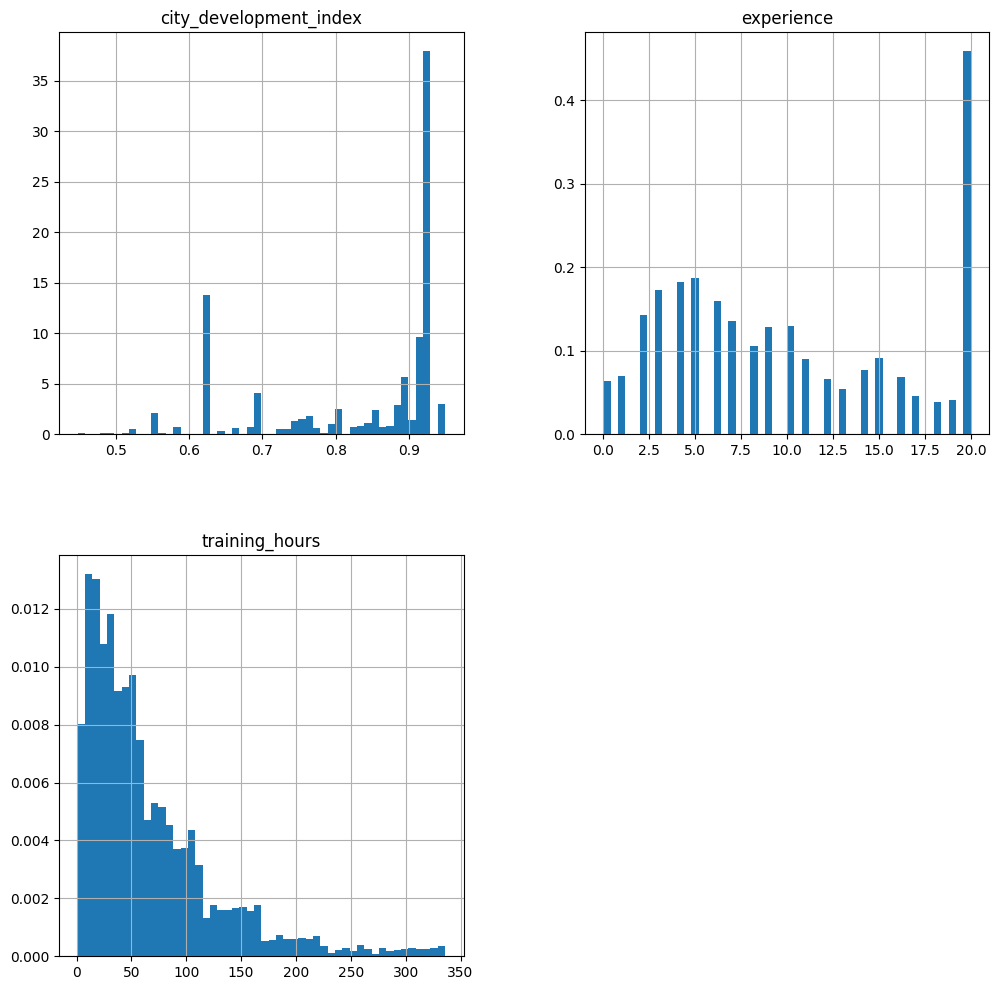

In [12]:
new_df.hist(bins=50, density=True, figsize=(12,12))

<Axes: >

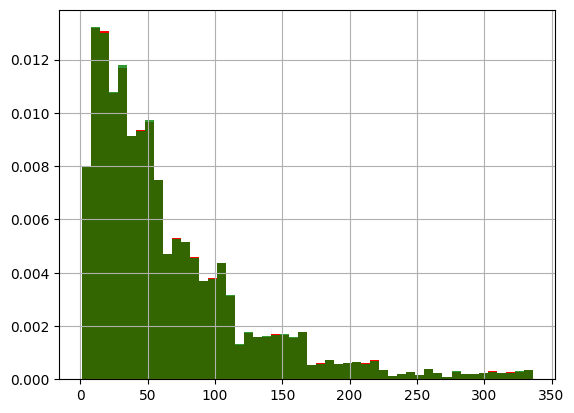

In [11]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['training_hours'].hist(bins=50, ax=ax, density=True, color='red')

# data after cca, the argument alpha makes the color transparent, so we can
# see the overlay of the 2 distributions
new_df['training_hours'].hist(bins=50, ax=ax, color='green', density=True, alpha=0.8)

<Axes: ylabel='Density'>

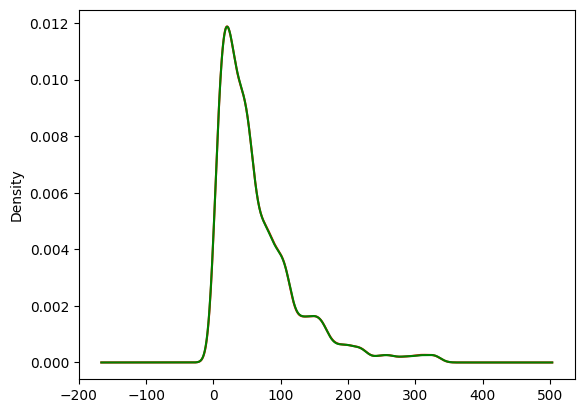

In [16]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['training_hours'].plot.density(color='red')

# data after cca
new_df['training_hours'].plot.density(color='green')

> For analysing before and after effect of CCA:

a. For numerical data ->
- Plot histogram and analyse the change
- If distributn is same then doing right
- Means values are MCAR

b. For Categorical data
- Categorical cols have diff categories
- So Check for Ratio of their distribtn before and after CCA

In [ ]:
# checking the ratio of categories before and after applying cca

temp = pd.concat([
    # %age of obs per category, original data
    df['enrolled_university'].value_counts() / len(df),

    # %age of obs per category, cca data
    new_df['enrolled_university'].value_counts() / len(new_df)
],
axis=1)

# add col names
temp.columns = ['original','cca']
temp

,original,cca
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


In [14]:
temp = pd.concat([
    # %age of obs per category, original data
    df['education_level'].value_counts() / len(df),

    # %age of obs per category, cca data
    new_df['education_level'].value_counts() / len(new_df)
],
axis=1)

# add col names
temp.columns = ['original','cca']
temp

,original,cca
education_level,,
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587
